Using cuda device
Using cuda device
Epoch  10/50  Loss=1.4582e+00  Valid Loss=4.2897e+00  LR=1.00e-03
Epoch  20/50  Loss=4.9043e-01  Valid Loss=9.4717e-01  LR=1.00e-03
Epoch  30/50  Loss=3.3364e-01  Valid Loss=5.5765e-01  LR=1.00e-03
Epoch  40/50  Loss=2.9732e-01  Valid Loss=5.1305e-01  LR=1.00e-03
Epoch  50/50  Loss=2.8742e-01  Valid Loss=4.9106e-01  LR=1.00e-03

Best model from epoch 50 with validation loss: 4.9106e-01
Epoch  10/50  Loss=3.2927e-01  Valid Loss=4.7511e-02  LR=1.00e-03
Epoch  20/50  Loss=2.1832e-01  Valid Loss=3.2591e-02  LR=1.00e-03
Epoch  30/50  Loss=1.8238e-01  Valid Loss=2.5251e-02  LR=1.00e-03
Epoch  40/50  Loss=1.5715e-01  Valid Loss=2.0497e-02  LR=1.00e-03
Epoch  50/50  Loss=1.4436e-01  Valid Loss=1.7869e-02  LR=1.00e-03

Best model from epoch 50 with validation loss: 1.7869e-02
Epoch  10/50  Loss=9.6203e-02  Valid Loss=9.0701e-03  LR=1.00e-03
Epoch  20/50  Loss=9.3871e-02  Valid Loss=8.4760e-03  LR=1.00e-03
Epoch  30/50  Loss=9.2462e-02  Valid Loss=8.2131e-03  

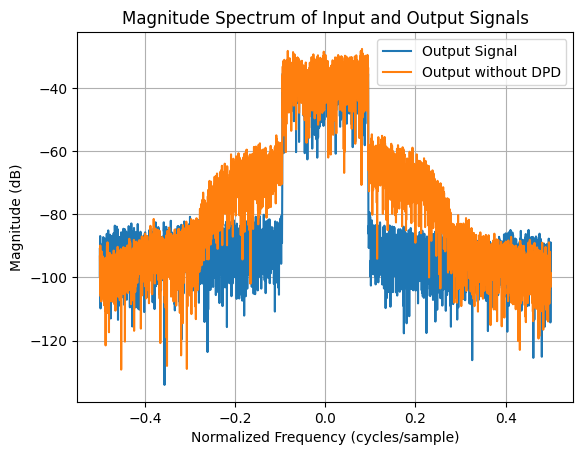

In [1]:
from sparseDPD import DataManager, DatapathPruningExperiment
from sparseDPD import Datapath
from sparseDPD import NeuralNetwork
from sparseDPD import PGJANET_NeuralNetwork
from sparseDPD.PNTDNN import PNTDNN_NeuralNetwork


# load pretrained model
simpleDataManager = DataManager(filepath='UCD_datasets/PA_IO.mat', num_training_points=19000, num_validaiton_points=1000, num_test_points=2000)

PGJANET_forward_nn = PGJANET_NeuralNetwork(nn_file_path='pre_trained_models/pgjanet_checkpoint.pt', num_memory_levels=10, model_type='PGJANETNetwork', forward_model=True)

# Train PNTDNN inverse model, but dont train yet. Use ILA training instead
PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', forward_model=False)


datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_inverse_nn)
datapath.train_using_ila(
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    iterations = 5,
    retrain_epochs_per_iteration=50
)

# find nmse
nmse = datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath.plot_spectrum(simpleDataManager.test_dataset.input_data[:5000])

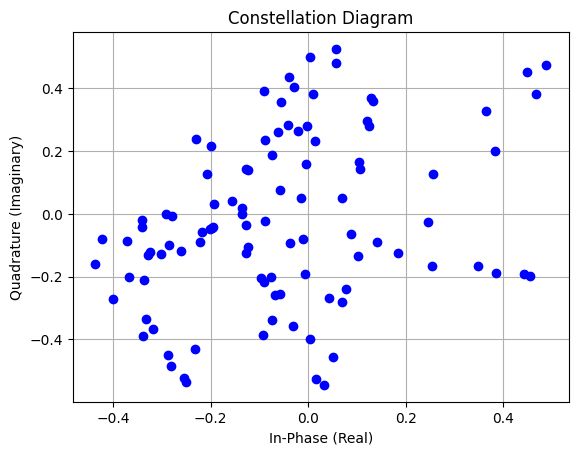

In [2]:
import matplotlib.pyplot as plt

# Load one of the other datasets to see if it is QAM
# Use OpenDPD dataset, store the folder containing the csv files
openDPD_folder = 'OpenDPD_datasets/APA_200MHz_b'

#40,000 points
openDPD_dataManager = DataManager(
    num_test_points=2000,
    num_training_points=23040,
    num_validaiton_points=7680,
    openDPD_test_input_file=f'{openDPD_folder}/test_input.csv',
    openDPD_test_output_file=f'{openDPD_folder}/test_output.csv',
    openDPD_training_input_file=f'{openDPD_folder}/train_input.csv',
    openDPD_training_output_file=f'{openDPD_folder}/train_output.csv',
    openDPD_validation_input_file=f'{openDPD_folder}/val_input.csv',
    openDPD_validation_output_file=f'{openDPD_folder}/val_output.csv'
)

for point in openDPD_dataManager.input_data[:100]:
    plt.plot(point.real, point.imag, 'bo')  # Plot real vs imag as blue dots
plt.title('Constellation Diagram')
plt.xlabel('In-Phase (Real)')
plt.ylabel('Quadrature (Imaginary)')
plt.grid()
plt.show()

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
ACLR with DPD - Lower: 33.90 dBc, Upper: 42.72 dBc
ACLR without DPD - Lower: 28.12 dBc, Upper: 27.79 dBc
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>


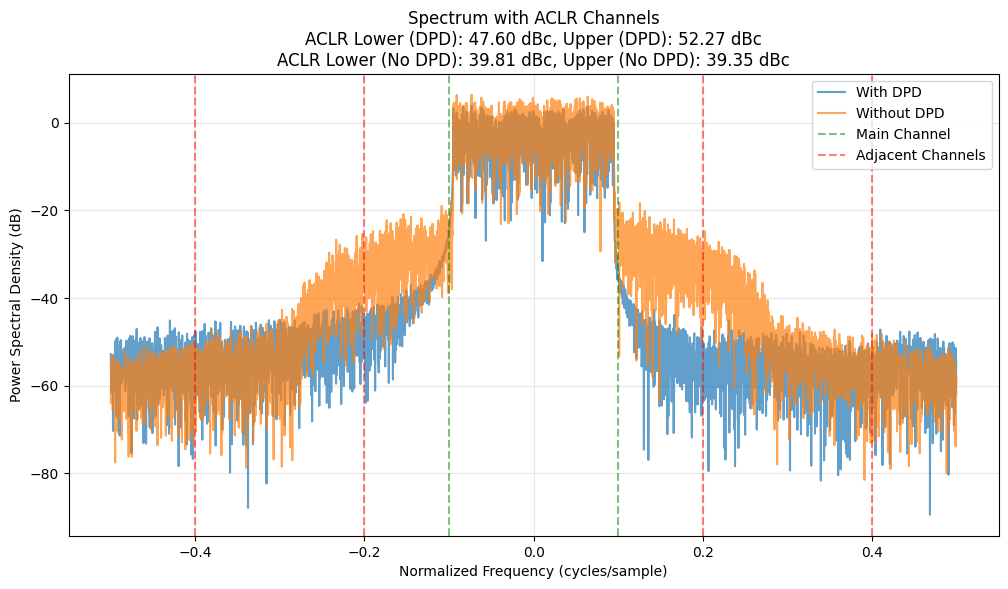

In [3]:
# Calculate ACLR metrics
aclr_results = datapath.calculate_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.1,        # Main channel bandwidth (10% of fs)
    channel_spacing=0.15,   # Adjacent channel offset (15% of fs)
    fs=1.0                  # Normalized sampling frequency
)

print(f"ACLR with DPD - Lower: {aclr_results['aclr_lower_dpd']:.2f} dBc, Upper: {aclr_results['aclr_upper_dpd']:.2f} dBc")
print(f"ACLR without DPD - Lower: {aclr_results['aclr_lower_no_dpd']:.2f} dBc, Upper: {aclr_results['aclr_upper_no_dpd']:.2f} dBc")

# Plot spectrum with ACLR channel boundaries marked
datapath.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>

Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 50 epochs...
Epoch  10/50  Loss=9.9191e-02  Valid Loss=8.1207e-03  LR=1.00e-03
Epoch  20/50  Loss=5.9475e-02  Valid Loss=6.6425e-03  LR=5.00e-04
Epoch  30/50  Loss=5.8610e-02  Valid Loss=7.2111e-03  LR=5.00e-04
Epoch  40/50  Loss=5.5240e-02  Valid Loss=6.3301e-03  LR=2.50e-04
Epoch  50/50  Loss=5.3563e-02  Valid Loss=6.6416e-03  LR=1.25e-04

Best model from epoch 38 with validation loss: 6.3107e-03
Epoch  10/50  Loss=6.8405e-02  Valid Loss=8.2946e-03  LR=1.00e-03
Epoch  20/50  Loss=6.8784e-02  Valid Loss=8.1436e-03  LR=1.00e-03
Epoch  30/50  Loss=8.5678e-02  Va

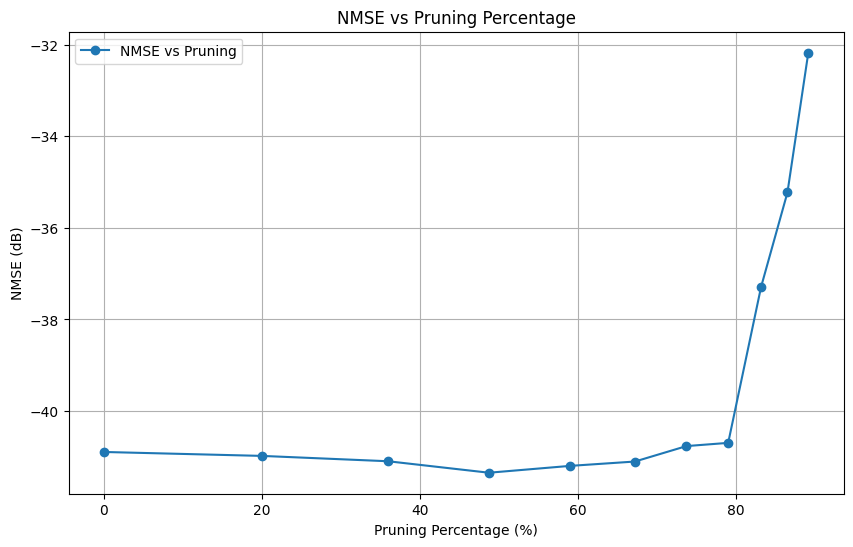

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Best NMSE after pruning: -40.6946 dB


In [4]:
# Now run the pruning experiment
pruning_experiment = DatapathPruningExperiment(
    datapath=datapath,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=50,
    ila_iterations = 5
)

pruning_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(pruning_experiment.best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)))

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Best NMSE after pruning: -40.6946 dB
Best model sparsity level: 79.03%
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>
Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PGJANET.PGJANET_NeuralNetwork'>


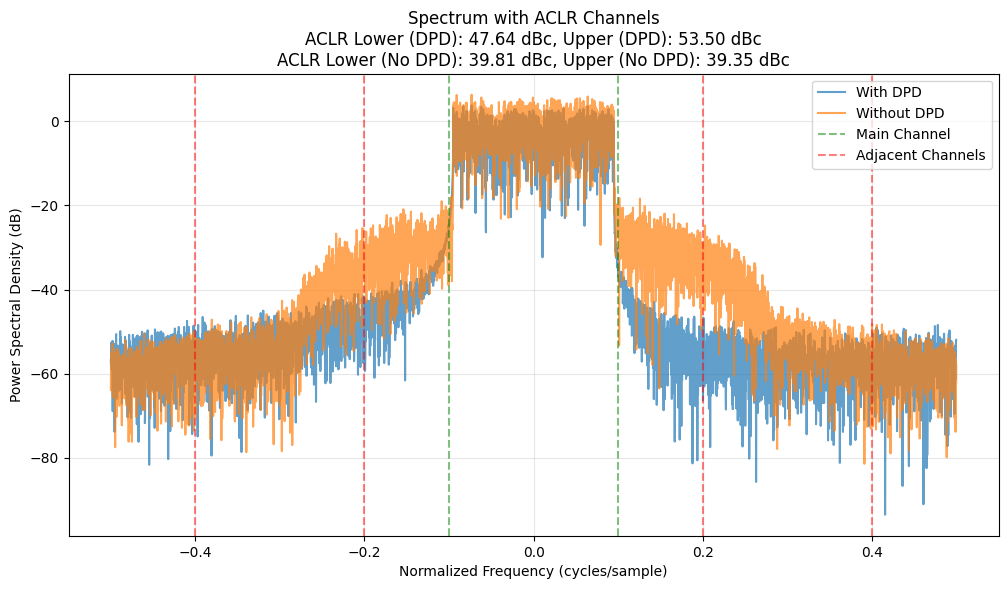

In [10]:
best_datapath = pruning_experiment.best_datapath
best_nmse = best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"Best NMSE after pruning: {best_nmse:.4f} dB")

# find the best model sparsity level
best_sparsity = best_datapath.inverse_model._get_pruning_percentage()
print(f"Best model sparsity level: {best_sparsity:.2f}%")

# Plot spectrum with ACLR channel boundaries marked
best_datapath.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)